# NFL Big Data Bowl 2025: GhostFormer Spatial Tracker


### 1. Environment Setup


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pytorch-lightning tensorboardX tensorboard

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.3 MB/s eta 0:00:00


In [6]:
import os

ROOT_DIR = "/content/drive/MyDrive/Projects/bdb-2025"
DATA_DIR = ROOT_DIR + "/data"
os.makedirs(DATA_DIR, exist_ok=True)
CKPT_DIR = ROOT_DIR + "/ckpt"
os.makedirs(CKPT_DIR, exist_ok=True)

### 2. Preprocessing Data Pipeline
This parses out relative line-of-scrimmage positional normalizations and filters data efficiently into PyTorch Tensor dictionaries (train & test splits).

In [7]:
import os
import polars as pl
import torch
import numpy as np
from tqdm import tqdm

def preprocess_weeks(weeks, split_name):
    print(f"Preprocessing {split_name} (weeks {weeks})...")
    players = pl.read_csv(f"{DATA_DIR}/players.csv", null_values=["NA", "nan", "N/A", "NaN", ""])
    plays = pl.read_csv(f"{DATA_DIR}/plays.csv", null_values=["NA", "nan", "N/A", "NaN", ""])

    # Pre-filter players to just what we need
    players_meta = players.select(["nflId", "displayName", "position"]).unique()
    plays_meta = plays.select("gameId", "playId", "defensiveTeam")

    all_frames = []

    for w in weeks:
        print(f"Loading tracking_week_{w}.csv...")
        if not os.path.exists(f"{DATA_DIR}/tracking_week_{w}.csv"):
            continue

        df = pl.read_csv(f"{DATA_DIR}/tracking_week_{w}.csv", null_values=["NA", "nan", "N/A", "NaN", ""])

        # Filter football and only keep BEFORE_SNAP
        df = df.filter((pl.col("displayName") != "football") & (pl.col("frameType") == "BEFORE_SNAP"))

        # Join plays and players
        df = df.join(plays_meta, on=["gameId", "playId"], how="inner")
        df = df.join(players_meta, on=["nflId", "displayName"], how="left")

        # Add isDefense
        df = df.with_columns(
            isDefense=pl.when(pl.col("club") == pl.col("defensiveTeam")).then(pl.lit(1)).otherwise(pl.lit(0))
        )

        # Drop players with missing position
        df = df.filter(pl.col("position").is_not_null())

        print(f"Computing middle points for week {w}...")
        centers = df.group_by(["gameId", "playId", "frameId", "isDefense"]).agg([
            pl.col("x").mean().alias("mean_x"),
            pl.col("y").mean().alias("mean_y"),
        ])

        middle = centers.group_by(["gameId", "playId", "frameId"]).agg([
            pl.col("mean_x").mean().alias("mid_x"),
            pl.col("mean_y").mean().alias("mid_y"),
        ])

        df = df.join(middle, on=["gameId", "playId", "frameId"], how="inner")

        # Normalize relative to middle point
        df = df.with_columns([
            (pl.col("x") - pl.col("mid_x")).alias("x_norm"),
            (pl.col("y") - pl.col("mid_y")).alias("y_norm"),
        ])

        # We need frames to have EXACTLY 22 players
        counts = df.group_by(["gameId", "playId", "frameId"]).agg(pl.col("nflId").n_unique().alias("unique_len"))
        valid_frames = counts.filter(pl.col("unique_len") == 22).select(["gameId", "playId", "frameId"])
        df = df.join(valid_frames, on=["gameId", "playId", "frameId"], how="inner")

        # Group to lists
        frames_df = df.group_by(["gameId", "playId", "frameId"]).agg([
            pl.col("nflId"),
            pl.col("position"),
            pl.col("isDefense"),
            pl.col("x_norm").alias("x"),
            pl.col("y_norm").alias("y"),
        ]).to_dicts()

        all_frames.extend(frames_df)
        print(f"Week {w} processed: {len(frames_df)} frames added.")

    print(f"Total {split_name} frames: {len(all_frames)}")
    torch.save(all_frames, f"{DATA_DIR}/{split_name}_frames.pt")


In [8]:
preprocess_weeks(list(range(1, 9)), "train")
preprocess_weeks([9], "test")

Preprocessing train (weeks [1, 2, 3, 4, 5, 6, 7, 8])...
Loading tracking_week_1.csv...
Computing middle points for week 1...
Week 1 processed: 184897 frames added.
Loading tracking_week_2.csv...
Computing middle points for week 2...
Week 2 processed: 175290 frames added.
Loading tracking_week_3.csv...
Computing middle points for week 3...
Week 3 processed: 186587 frames added.
Loading tracking_week_4.csv...
Computing middle points for week 4...
Week 4 processed: 175503 frames added.
Loading tracking_week_5.csv...
Computing middle points for week 5...
Week 5 processed: 187004 frames added.
Loading tracking_week_6.csv...
Computing middle points for week 6...
Week 6 processed: 162257 frames added.
Loading tracking_week_7.csv...
Computing middle points for week 7...
Week 7 processed: 149609 frames added.
Loading tracking_week_8.csv...
Computing middle points for week 8...
Week 8 processed: 161662 frames added.
Total train frames: 1382809
Preprocessing test (weeks [9])...
Loading tracking_w

### 3. Dynamic Masked Dataset
Loads the sequential structures and seamlessly interleaves the 11 possible defensive masks dynamically at the loading stage.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

DEFENSE_POSITIONS = ["CB", "S", "FS", "SS", "LB", "MLB", "OLB", "DE", "DT", "NT"]
POSITIONS = sorted(['C', 'CB', 'DB', 'DE', 'DT', 'FB', 'FS', 'G', 'ILB', 'LB', 'LS', 'MLB', 'NT', 'OLB', 'QB', 'RB', 'S', 'SS', 'T', 'TE', 'WR'])
POS_TO_IDX = {p: i for i, p in enumerate(POSITIONS)}

MAX_SEQ_LEN = 50

class MaskedPlayerDataset(Dataset):
    def __init__(self, frames_path):
        raw_frames = torch.load(frames_path, weights_only=False)

        # Group frames into plays
        plays = {}
        for frame in raw_frames:
            # Enforce strict player ordering by nflId
            nflIds = frame['nflId']
            sort_idx = np.argsort(nflIds)
            frame['nflId'] = [frame['nflId'][i] for i in sort_idx]
            frame['position'] = [frame['position'][i] for i in sort_idx]
            frame['isDefense'] = [frame['isDefense'][i] for i in sort_idx]
            frame['x'] = [frame['x'][i] for i in sort_idx]
            frame['y'] = [frame['y'][i] for i in sort_idx]

            k = (frame['gameId'], frame['playId'])
            if k not in plays:
                plays[k] = []
            plays[k].append(frame)

        self.samples = []
        self.plays_list = []

        play_idx = 0
        for k in plays:
            # Sort by frameId natively (frameId increments chronologically)
            play_frames = sorted(plays[k], key=lambda f: f['frameId'])

            # constrain to MAX_SEQ_LEN
            play_frames = play_frames[:MAX_SEQ_LEN]
            self.plays_list.append(play_frames)

            is_def = [i for i in range(22) if play_frames[0]['isDefense'][i] == 1]
            for p_idx in is_def:
                self.samples.append((play_idx, p_idx))
            play_idx += 1

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        play_idx, mask_idx = self.samples[idx]
        play = self.plays_list[play_idx]
        seq_len = len(play)

        numeric_seq = np.zeros((MAX_SEQ_LEN, 22, 3), dtype=np.float32)
        pos_seq = np.zeros((MAX_SEQ_LEN, 22), dtype=np.int64)
        target_seq = np.zeros((MAX_SEQ_LEN, 2), dtype=np.int64)
        valid_mask = np.zeros((MAX_SEQ_LEN,), dtype=np.float32)

        for t, frame in enumerate(play):
            xs = np.array(frame["x"], dtype=np.float32)
            ys = np.array(frame["y"], dtype=np.float32)

            numeric = np.stack([xs, ys, np.zeros_like(xs)], axis=-1)
            target_x = min(max(int(xs[mask_idx] + 60), 0), 119)
            target_y = min(max(int(ys[mask_idx] + 30), 0), 59)

            target_seq[t] = [target_x, target_y]

            numeric[mask_idx, 0] = 0.0
            numeric[mask_idx, 1] = 0.0
            numeric[mask_idx, 2] = 1.0

            numeric_seq[t] = numeric
            pos_seq[t] = np.array([POS_TO_IDX.get(p, 0) for p in frame["position"]], dtype=np.int64)
            valid_mask[t] = 1.0

        return {
            "numeric": torch.from_numpy(numeric_seq),   # (T, 22, 3)
            "pos_ids": torch.from_numpy(pos_seq),       # (T, 22)
            "mask_idx": torch.tensor(mask_idx, dtype=torch.long),
            "target": torch.from_numpy(target_seq),     # (T, 2)
            "valid_mask": torch.from_numpy(valid_mask)  # (T,)
        }

def get_dataloader(frames_path, batch_size=64, shuffle=True, num_workers=4):
    ds = MaskedPlayerDataset(frames_path)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=num_workers)


### 4. Transformer Architectures (GhostFormer)
Instantiates the underlying transformer handling `mean` and `logvar` probabilistic spatial predictions optimized by Gaussian NLL.

In [10]:
import torch
import torch.nn as nn
from pytorch_lightning import LightningModule

torch.set_float32_matmul_precision("medium")

class GhostFormer(nn.Module):
    def __init__(
        self,
        num_positions: int = 21,
        pos_emb_dim: int = 16,
        model_dim: int = 64,
        num_layers: int = 3,
        num_heads: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.numeric_dim = 3
        self.pos_embedding = nn.Embedding(num_positions, pos_emb_dim)
        in_dim = self.numeric_dim + pos_emb_dim

        self.input_projection = nn.Sequential(
            nn.Linear(in_dim, model_dim),
            nn.LayerNorm(model_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # Spatial Encoder (inter-player)
        spatial_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, dim_feedforward=model_dim*4, dropout=dropout, batch_first=True
        )
        self.spatial_transformer = nn.TransformerEncoder(spatial_layer, num_layers=num_layers)

        # Temporal Encoder (frame-to-frame)
        temporal_layer = nn.TransformerEncoderLayer(
            d_model=model_dim, nhead=num_heads, dim_feedforward=model_dim*4, dropout=dropout, batch_first=True
        )
        self.temporal_transformer = nn.TransformerEncoder(temporal_layer, num_layers=2)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(model_dim, model_dim // 2),
            nn.GELU(),
            nn.LayerNorm(model_dim // 2),
            nn.Linear(model_dim // 2, 120 + 60) # X(120), Y(60)
        )

    def forward(self, numeric, pos_ids, mask_idx, valid_mask):
        # numeric: (B, T, 22, 3), pos_ids: (B, T, 22), mask_idx: (B,), valid_mask: (B, T)
        B, T, seq_len, _ = numeric.shape

        # Collapse B and T for spatial attention
        numeric_flat = numeric.view(B*T, seq_len, 3)
        pos_ids_flat = pos_ids.view(B*T, seq_len)

        pos_embs = self.pos_embedding(pos_ids_flat)
        x = torch.cat([numeric_flat, pos_embs], dim=-1)
        x = self.input_projection(x)

        x = self.spatial_transformer(x) # (B*T, 22, model_dim)

        # Gather masked token
        mask_idx_flat = mask_idx.unsqueeze(1).repeat(1, T).view(-1).to(x.device)
        batch_indices = torch.arange(B*T, device=x.device)
        masked_token_repr = x[batch_indices, mask_idx_flat] # (B*T, model_dim)

        # Restore T dimension for temporal processing
        masked_token_seq = masked_token_repr.view(B, T, -1) # (B, T, model_dim)

        # Generate padding mask for temporal transformer
        # In PyTorch, padding_mask True means IGNORE. Our valid_mask is 1 for valid, 0 for pad.
        src_key_padding_mask = (valid_mask == 0).to(x.device)

        t_out = self.temporal_transformer(masked_token_seq, src_key_padding_mask=src_key_padding_mask) # (B, T, model_dim)

        output = self.decoder(t_out) # (B, T, 180)
        logits_x = output[:, :, :120]
        logits_y = output[:, :, 120:]
        return logits_x, logits_y

class GhostFormerLitModel(LightningModule):
    def __init__(self, learning_rate: float = 1e-3, weight_decay: float = 1e-4):
        super().__init__()
        self.save_hyperparameters()
        self.model = GhostFormer()

    def forward(self, numeric, pos_ids, mask_idx, valid_mask):
        return self.model(numeric, pos_ids, mask_idx, valid_mask)

    def classification_loss(self, logits_x, logits_y, target, valid_mask):
        loss_fn = nn.CrossEntropyLoss(reduction='none')
        # Flatten for loss computation
        logits_x_flat = logits_x.reshape(-1, 120)
        logits_y_flat = logits_y.reshape(-1, 60)
        target_flat = target.reshape(-1, 2)
        valid_flat = valid_mask.reshape(-1)

        loss_x = loss_fn(logits_x_flat, target_flat[:, 0])
        loss_y = loss_fn(logits_y_flat, target_flat[:, 1])

        # Mask out padded positions
        total_loss = ((loss_x + loss_y) * valid_flat).sum() / (valid_flat.sum() + 1e-6)
        return total_loss

    def training_step(self, batch, batch_idx):
        numeric, pos_ids, mask_idx = batch["numeric"], batch["pos_ids"], batch["mask_idx"]
        target, valid_mask = batch["target"], batch["valid_mask"]

        logits_x, logits_y = self(numeric, pos_ids, mask_idx, valid_mask)
        loss = self.classification_loss(logits_x, logits_y, target, valid_mask)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        numeric, pos_ids, mask_idx = batch["numeric"], batch["pos_ids"], batch["mask_idx"]
        target, valid_mask = batch["target"], batch["valid_mask"]

        logits_x, logits_y = self(numeric, pos_ids, mask_idx, valid_mask)
        loss = self.classification_loss(logits_x, logits_y, target, valid_mask)

        self.log("val_loss", loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.hparams.learning_rate, weight_decay=self.hparams.weight_decay)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)
        return {"optimizer": optimizer, "lr_scheduler": {"scheduler": scheduler, "monitor": "val_loss"}}


### 5. PyTorch Lightning Trainer
Configured routine to process through the augmented set, evaluate, and save checkpoints.

In [24]:
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping
from pytorch_lightning.loggers import TensorBoardLogger
import torch
import warnings




warnings.filterwarnings("ignore")

def main():
    pl.seed_everything(42)

    # We use part of train frames for training, part for val.
    # Since we saved everything together in train_frames.pt, let's load it.
    print("Loading datasets...")
    full_dataset = MaskedPlayerDataset(f"{DATA_DIR}/train_frames.pt")

    train_size = int(0.9 * len(full_dataset))
    val_size = len(full_dataset) - train_size
    train_ds, val_ds = torch.utils.data.random_split(full_dataset, [train_size, val_size])

    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
    val_loader = torch.utils.data.DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)

    model = GhostFormerLitModel(learning_rate=3e-4)

    logger = TensorBoardLogger("tb_logs", name="ghost_former")
    checkpoint_callback = ModelCheckpoint(
        monitor="val_loss",
        dirpath=CKPT_DIR,
        filename="ghost_former-{epoch:02d}-{val_loss:.2f}",
        save_top_k=1,
        mode="min",
    )
    early_stop_callback = EarlyStopping(monitor="val_loss", min_delta=0.00, patience=3, verbose=False, mode="min")

    trainer = pl.Trainer(
        max_epochs=100,  # Short max epochs for quick test, set higher in practice
        logger=logger,
        callbacks=[checkpoint_callback, early_stop_callback],
        accelerator="auto",
        devices=1,
        log_every_n_steps=50,
        val_check_interval=0.5
    )

    print("Starting training...")
    trainer.fit(model, train_loader, val_loader)


In [25]:
main()

INFO:lightning_fabric.utilities.seed:Seed set to 42


Loading datasets...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting training...


┏━━━┳━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ GhostFormer │  259 K │ train │     0 │
└───┴───────┴─────────────┴────────┴───────┴───────┘

Trainable params: 259 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 259 K                                                                                                
Total estimated model params size (MB): 1                                                                          
Modules in train mode: 66                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

### 6. Evaluation on Week 9 Hold-out
Provides aggregate predictive tracking precision logic.

In [26]:
import torch
import pytorch_lightning as pl
from torch.utils.data import DataLoader


import glob

def evaluate():
    print("Loading test dataset (Week 9)...")
    test_dataset = MaskedPlayerDataset(f"{DATA_DIR}/test_frames.pt")
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

    ckpt_files = glob.glob(f"{CKPT_DIR}/*.ckpt")
    if ckpt_files:
        print(f"Loading model from checkpoint {ckpt_files[0]}")
        model = GhostFormerLitModel.load_from_checkpoint(ckpt_files[0])
    else:
        model = GhostFormerLitModel()

    model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    total_mse = 0
    count = 0

    print("Evaluating Spatiotemporal Metrics...")
    with torch.no_grad():
        for batch in test_loader:
            numeric, pos_ids, mask_idx = batch["numeric"].to(device), batch["pos_ids"].to(device), batch["mask_idx"].to(device)
            target, valid_mask = batch["target"].to(device), batch["valid_mask"].to(device)

            logits_x, logits_y = model(numeric, pos_ids, mask_idx, valid_mask)

            # Predict coordinates
            pred_x = logits_x.argmax(dim=-1).float() - 60
            pred_y = logits_y.argmax(dim=-1).float() - 30
            pred_mean = torch.stack([pred_x, pred_y], dim=-1) # (B, T, 2)

            true_x = target[:, :, 0].float() - 60
            true_y = target[:, :, 1].float() - 30
            target_mean = torch.stack([true_x, true_y], dim=-1)

            # Mask out padding in MSE
            diff_sq = ((pred_mean - target_mean) ** 2)
            mse = (diff_sq.sum(dim=-1) * valid_mask).sum().item()

            total_mse += mse
            count += valid_mask.sum().item() * 2 # 2 coordinates per valid frame

    print("-"*40)
    print("EVALUATION RESULTS (WEEK 9)")
    print(f"Mean Squared Error (MSE): {total_mse/count:.4f}")
    print("-"*40)


In [27]:
evaluate()

Loading test dataset (Week 9)...
Loading model from checkpoint /content/drive/MyDrive/Projects/bdb-2025/ckpt/ghost_former-epoch=01-val_loss=2.89.ckpt
Evaluating Spatiotemporal Metrics...
----------------------------------------
EVALUATION RESULTS (WEEK 9)
Mean Squared Error (MSE): 1.9085
----------------------------------------


### 7. Trajectory Visualizations
Extracts the sequence map per chronological play and outputs the variance/prediction tracks onto an MP4 output. (Downloads/Displays directly within Colab).

In [28]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
import glob
import random




def draw_field(ax):
    ax.set_facecolor('#E6F5E6')
    ax.set_xlim(-40, 40)
    ax.set_ylim(-30, 30)
    for i in range(-40, 41, 5):
        ax.axvline(i, color='white', alpha=0.5, linestyle='-', zorder=0)
    for i in range(-40, 41, 1):
        ax.plot([i, i], [-1, 1], color='white', alpha=0.3, zorder=0)
        ax.plot([i, i], [29, 31], color='white', alpha=0.3, zorder=0)
        ax.plot([i, i], [-29, -31], color='white', alpha=0.3, zorder=0)
    ax.axis('off')

def get_ellipse(mean_x, mean_y, cur_var, n_std=1.0, **kwargs):
    width = 2 * n_std * cur_var
    height = 2 * n_std * cur_var
    return Ellipse(xy=(mean_x, mean_y), width=width, height=height, **kwargs)

def run_visualization():
    print("Loading test frames for visualization...")
    try:
        frames = torch.load(f"{DATA_DIR}/test_frames.pt", weights_only=False)
    except FileNotFoundError:
        print("test_frames.pt not found.")
        return

    plays = {}
    for frame in frames:
        nflIds = frame['nflId']
        sort_idx = np.argsort(nflIds)
        frame['nflId'] = [frame['nflId'][i] for i in sort_idx]
        frame['position'] = [frame['position'][i] for i in sort_idx]
        frame['isDefense'] = [frame['isDefense'][i] for i in sort_idx]
        frame['x'] = [frame['x'][i] for i in sort_idx]
        frame['y'] = [frame['y'][i] for i in sort_idx]
        k = (frame['gameId'], frame['playId'])
        if k not in plays: plays[k] = []
        plays[k].append(frame)

    valid_plays = [k for k, v in plays.items() if len(v) >= 15]
    selected_key = random.choice(valid_plays) if valid_plays else list(plays.keys())[0]
    play_frames = sorted(plays[selected_key], key=lambda f: f['frameId'])[:50]
    T_len = len(play_frames)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ckpt_files = glob.glob(f"{CKPT_DIR}/*.ckpt")
    model = GhostFormerLitModel.load_from_checkpoint(ckpt_files[0]) if ckpt_files else GhostFormerLitModel()
    model.to(device)
    model.eval()

    mask_target_idx = [i for i, is_def in enumerate(play_frames[0]['isDefense']) if is_def == 1][0]

    history_actual_x, history_actual_y = [], []
    all_player_coords = []

    numeric_seq = np.zeros((1, T_len, 22, 3), dtype=np.float32)
    pos_seq = np.zeros((1, T_len, 22), dtype=np.int64)
    valid_mask = np.ones((1, T_len), dtype=np.float32)

    for t, frame in enumerate(play_frames):
        xs = np.array(frame['x'], dtype=np.float32)
        ys = np.array(frame['y'], dtype=np.float32)
        history_actual_x.append(xs[mask_target_idx])
        history_actual_y.append(ys[mask_target_idx])

        numeric = np.stack([xs, ys, np.zeros_like(xs)], axis=-1)
        numeric[mask_target_idx, 0] = 0.0
        numeric[mask_target_idx, 1] = 0.0
        numeric[mask_target_idx, 2] = 1.0

        numeric_seq[0, t] = numeric
        pos_seq[0, t] = np.array([POS_TO_IDX.get(p, 0) for p in frame['position']], dtype=np.int64)

        coords = [(xs[p], ys[p], frame['isDefense'][p]) for p in range(22) if p != mask_target_idx]
        all_player_coords.append(coords)

    with torch.no_grad():
        num_t = torch.from_numpy(numeric_seq).to(device)
        pos_t = torch.from_numpy(pos_seq).to(device)
        mask_t = torch.tensor([mask_target_idx], dtype=torch.long).to(device)
        valid_t = torch.from_numpy(valid_mask).to(device)

        logits_x, logits_y = model(num_t, pos_t, mask_t, valid_t) # (1, T, classes)
        px_arr = logits_x[0].argmax(dim=-1).cpu().numpy() - 60
        py_arr = logits_y[0].argmax(dim=-1).cpu().numpy() - 30

        # Uncertainty emulation
        probs_x = torch.softmax(logits_x[0], dim=-1).cpu().numpy()
        max_px = probs_x.max(axis=-1)
        var_proxy = -np.log(max_px + 1e-4) * 2

    fig, ax = plt.subplots(figsize=(10, 6))

    def update(t):
        ax.clear()
        draw_field(ax)

        cur_coords = all_player_coords[t]
        off_x, off_y = [c[0] for c in cur_coords if c[2]==0], [c[1] for c in cur_coords if c[2]==0]
        def_x, def_y = [c[0] for c in cur_coords if c[2]==1], [c[1] for c in cur_coords if c[2]==1]

        ax.scatter(off_x, off_y, color='red', s=50, label='Offense', edgecolors='white', zorder=3)
        ax.scatter(def_x, def_y, color='blue', s=50, label='Defense', edgecolors='white', zorder=3)

        ax.scatter([history_actual_x[t]], [history_actual_y[t]], color='blue', s=80, marker='X', edgecolors='black', label='Target True', zorder=4)
        if t > 0:
            ax.plot(px_arr[:t+1], py_arr[:t+1], color='orange', linestyle='--', linewidth=2, zorder=2)

        cur_px, cur_py, cur_var = px_arr[t], py_arr[t], var_proxy[t]
        ax.scatter([cur_px], [cur_py], color='orange', s=80, marker='*', edgecolors='black', label='Predicted', zorder=5)
        ax.add_patch(get_ellipse(cur_px, cur_py, cur_var, alpha=0.3, color='orange', zorder=1))
        ax.set_title(f"Play Tracking: Game {selected_key[0]} - Play {selected_key[1]} | Frame {t+1}/{T_len}")
        ax.legend(loc='lower right')

    anim = FuncAnimation(fig, update, frames=T_len, interval=100)
    anim.save(f'{ROOT_DIR}/visualization.mp4', writer='ffmpeg', fps=10)
    print("Saved visualization.mp4")

Loading test frames for visualization...
Saved visualization.mp4


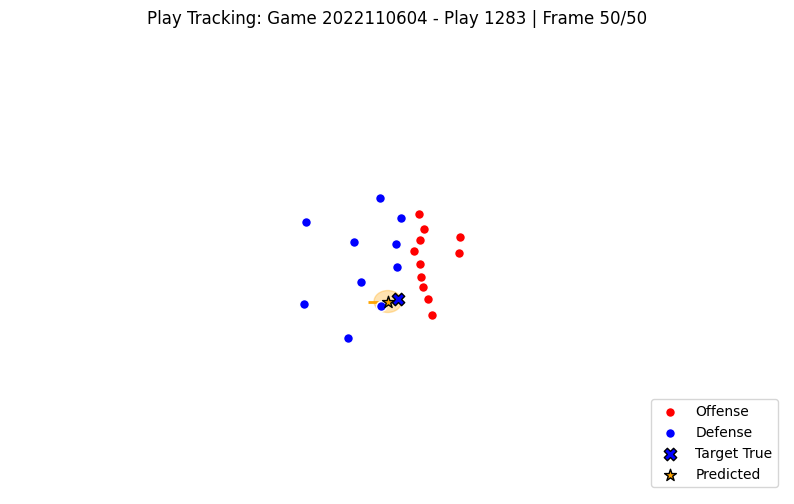

In [29]:
run_visualization()

In [30]:
from IPython.display import Video

Video(f'{ROOT_DIR}/visualization.mp4', embed=True)